DATA QUALITY CHECK REPORT

Dataset Shape: 70,000 rows × 26 columns
Memory Usage: 61.62 MB

DATA TYPES OVERVIEW
                  Column Data Type  Non-Null Count  Null Count   Null %  Unique Values               Sample Value
              CustomerID    object           70000           0 0.000000          70000                CUST_000001
                     Age     int64           70000           0 0.000000             63                         49
                  Gender    object           70000           0 0.000000              3                     Female
                    City    object           70000           0 0.000000             10                 Kermanshah
              SignupDate    object           70000           0 0.000000          69275 2025-05-26 14:23:29.983815
            TenureMonths     int64           70000           0 0.000000            120                         11
DaysSinceLastInteraction     int64           70000           0 0.000000            136     

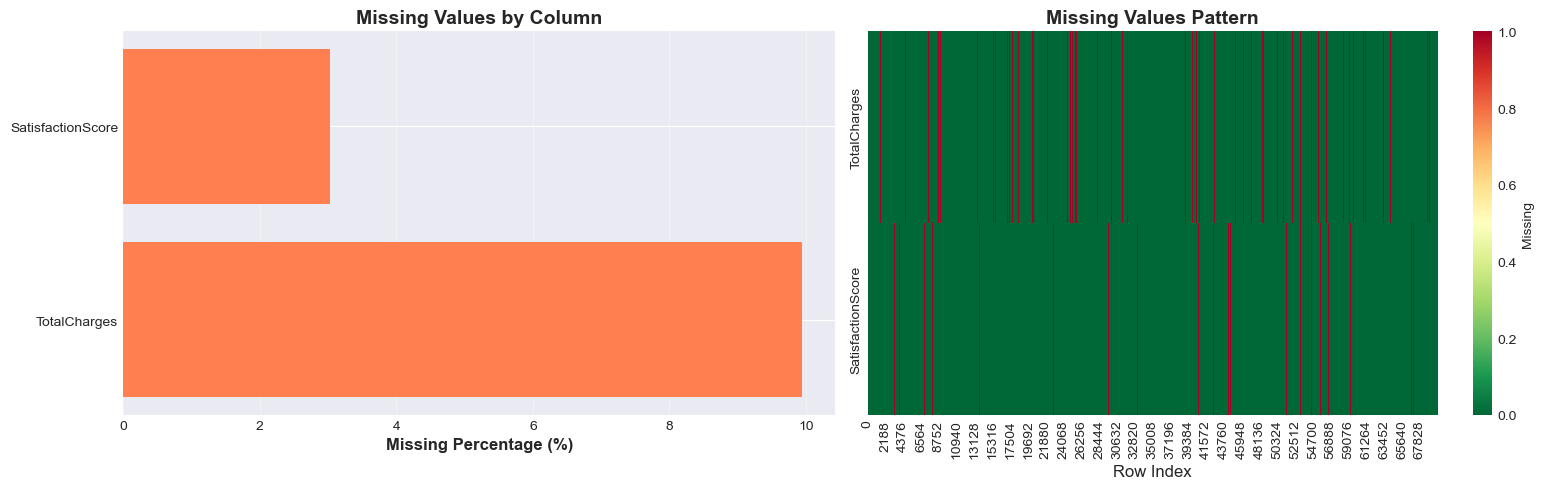


DUPLICATE RECORDS CHECK
Duplicate CustomerIDs: 0
Duplicate Rows (all columns): 0
✓ No duplicate rows found!

NUMERICAL FEATURES STATISTICS

Numerical Columns: 11
                            count         mean          std   min     25%  \
Age                       70000.0    41.881071    14.176603  18.0   31.00   
TenureMonths              70000.0    23.455814    23.264607   1.0    6.00   
DaysSinceLastInteraction  70000.0    14.436471    14.875894   0.0    4.00   
MonthlyCharges            70000.0    52.308283    27.065964  15.0   32.23   
TotalCharges              63047.0  1509.860473  1934.631322   0.0  335.20   
NumProducts               70000.0     3.518229     1.558970   0.0    3.00   
SupportCalls              70000.0     2.744843     2.430096   0.0    1.00   
SatisfactionScore         67879.0     7.000234     1.384037   1.0    6.10   
AvgMonthlyUsageGB         70000.0    60.417327    52.485548   0.0   18.20   
LatePayments              70000.0     0.680800     0.997846   0.0  

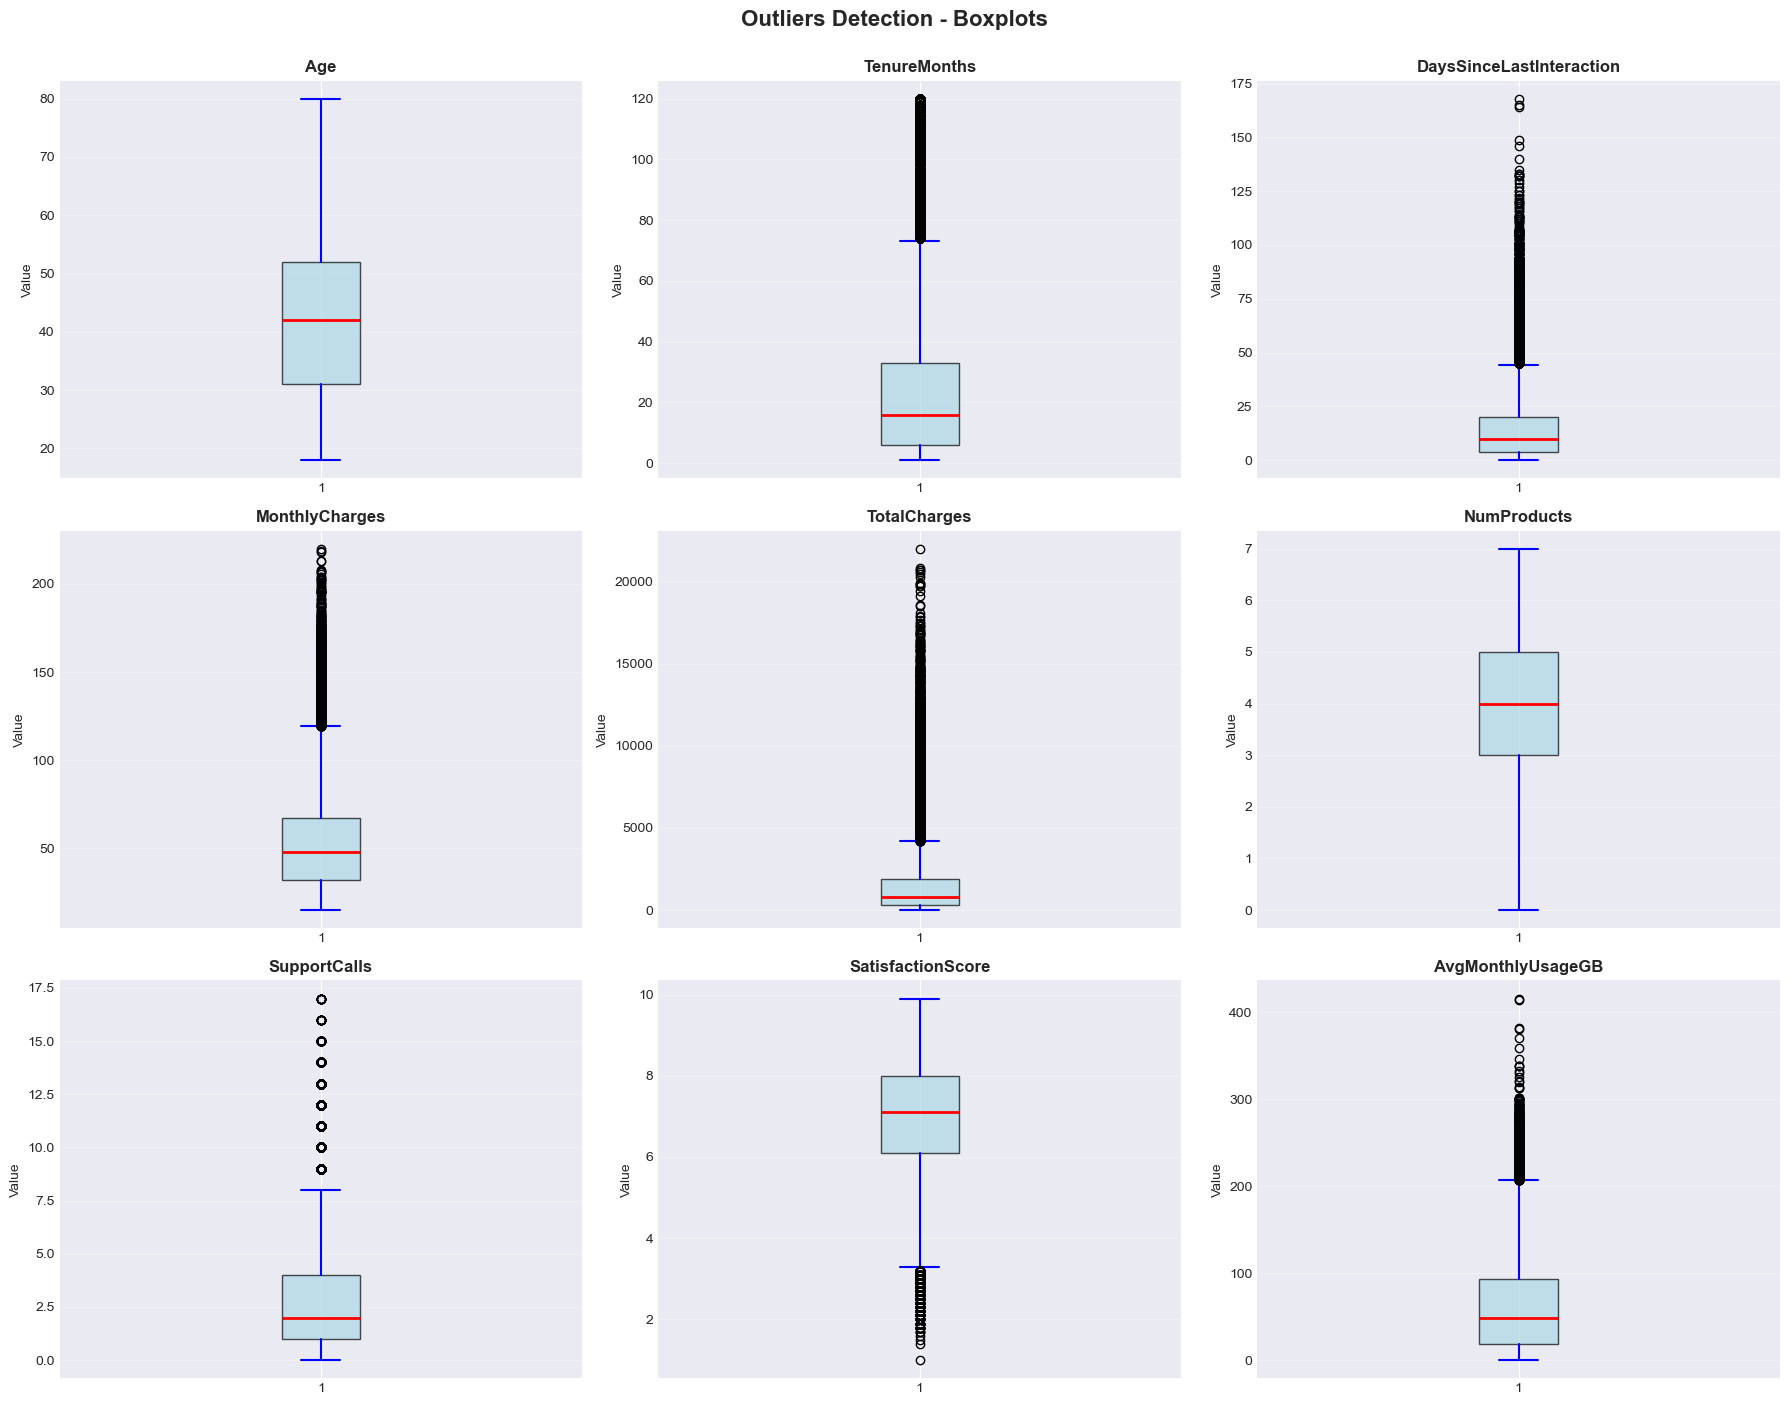


CATEGORICAL FEATURES ANALYSIS

Categorical Columns: 13
          Column  Unique Values    Most Frequent  Most Frequent Count  Most Frequent %
          Gender              3           Female                35063        50.090000
            City             10           Tehran                17446        24.922857
    ContractType              3          Monthly                38590        55.128571
    PhoneService              2              Yes                59516        85.022857
   MultipleLines              3               No                34453        49.218571
 InternetService              3            Fiber                35049        50.070000
  OnlineSecurity              3               No                35694        50.991429
    OnlineBackup              3               No                32626        46.608571
     TechSupport              3               No                38651        55.215714
     StreamingTV              3               No                30739     

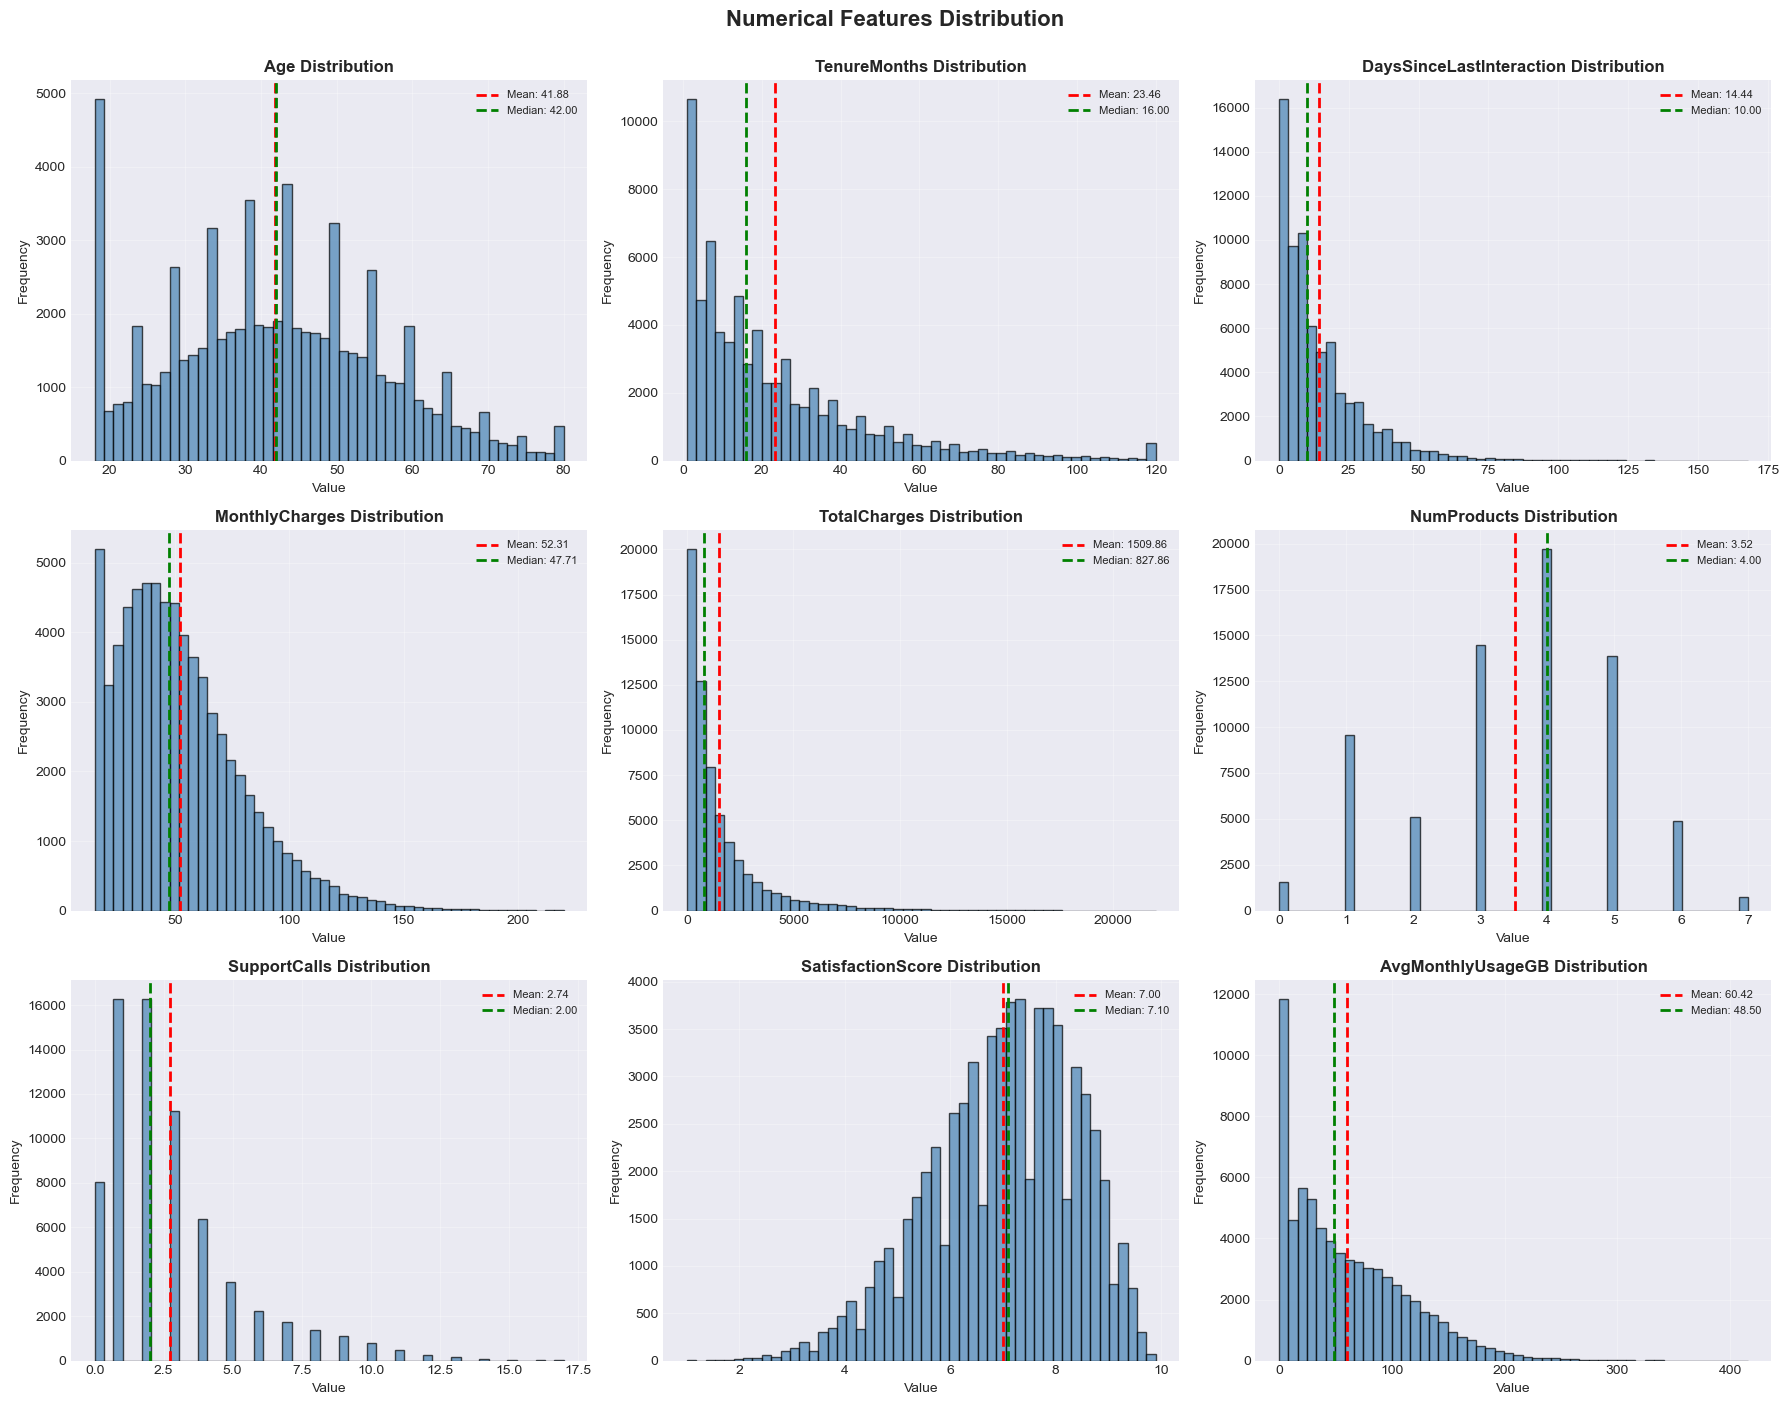


DATA QUALITY SUMMARY
✗ Missing Values: -6.48 points
✗ Outliers: -1.90 points

OVERALL DATA QUALITY SCORE: 91.62/100
✓ Excellent data quality!

DATA QUALITY CHECK COMPLETED


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# NOTEBOOK 02: DATA QUALITY CHECK
# Purpose: Comprehensive data quality assessment and validation
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ═══════════════════════════════════════════════════════════════════════════════

df = pd.read_csv('../data/raw/customer_churn_dataset.csv')

print("="*80)
print("DATA QUALITY CHECK REPORT")
print("="*80)
print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# ═══════════════════════════════════════════════════════════════════════════════
# 2. DATA TYPES OVERVIEW
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("DATA TYPES OVERVIEW")
print("="*80)

dtype_summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.count().values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum() / len(df) * 100).values,
    'Unique Values': df.nunique().values,
    'Sample Value': [df[col].dropna().iloc[0] if not df[col].dropna().empty else None for col in df.columns]
})

print(dtype_summary.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════
# 3. MISSING VALUES ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum() / len(df) * 100).values
})
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_data) > 0:
    print(missing_data.to_string(index=False))
    
    # Visualization vmissing values
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Bar plot
    axes[0].barh(missing_data['Column'], missing_data['Missing %'], color='coral')
    axes[0].set_xlabel('Missing Percentage (%)', fontsize=12, fontweight='bold')
    axes[0].set_title('Missing Values by Column', fontsize=14, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Heatmap
    missing_matrix = df[missing_data['Column']].isnull().astype(int)
    sns.heatmap(missing_matrix.T, cmap='RdYlGn_r', cbar_kws={'label': 'Missing'}, 
                ax=axes[1], yticklabels=missing_data['Column'])
    axes[1].set_title('Missing Values Pattern', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Row Index', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('../data/results/02_missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("✓ No missing values found in the dataset!")

# ═══════════════════════════════════════════════════════════════════════════════
# 4. DUPLICATE RECORDS CHECK
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("DUPLICATE RECORDS CHECK")
print("="*80)

# duplicate base CustomerID
duplicate_ids = df['CustomerID'].duplicated().sum()
print(f"Duplicate CustomerIDs: {duplicate_ids}")

# duplicate base all
duplicate_rows = df.duplicated().sum()
print(f"Duplicate Rows (all columns): {duplicate_rows}")

if duplicate_rows > 0:
    print(f"\n⚠ Warning: {duplicate_rows} duplicate rows found!")
else:
    print("✓ No duplicate rows found!")

# ═══════════════════════════════════════════════════════════════════════════════
# 5. NUMERICAL FEATURES ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("NUMERICAL FEATURES STATISTICS")
print("="*80)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumerical Columns: {len(numerical_cols)}")
print(df[numerical_cols].describe().T)

# ═══════════════════════════════════════════════════════════════════════════════
# 6. OUTLIERS DETECTION
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("OUTLIERS DETECTION (IQR Method)")
print("="*80)

outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100
    
    outlier_summary.append({
        'Column': col,
        'Outlier Count': outlier_count,
        'Outlier %': outlier_pct,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df[outlier_df['Outlier Count'] > 0].sort_values('Outlier %', ascending=False)

if len(outlier_df) > 0:
    print(outlier_df.to_string(index=False))
else:
    print("✓ No outliers detected!")

# Visualization outliers
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:9]):
    axes[idx].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2),
                      whiskerprops=dict(color='blue', linewidth=1.5),
                      capprops=dict(color='blue', linewidth=1.5))
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Value', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Outliers Detection - Boxplots', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/results/02_outliers_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 7. CATEGORICAL FEATURES ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("CATEGORICAL FEATURES ANALYSIS")
print("="*80)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
# حذف CustomerID و SignupDate
categorical_cols = [col for col in categorical_cols if col not in ['CustomerID', 'SignupDate']]

print(f"\nCategorical Columns: {len(categorical_cols)}")

cat_summary = []
for col in categorical_cols:
    cat_summary.append({
        'Column': col,
        'Unique Values': df[col].nunique(),
        'Most Frequent': df[col].mode()[0] if not df[col].mode().empty else None,
        'Most Frequent Count': df[col].value_counts().iloc[0] if len(df[col].value_counts()) > 0 else 0,
        'Most Frequent %': (df[col].value_counts().iloc[0] / len(df) * 100) if len(df[col].value_counts()) > 0 else 0
    })

cat_df = pd.DataFrame(cat_summary)
print(cat_df.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════
# 8. DATA DISTRIBUTION OVERVIEW
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("DATA DISTRIBUTION OVERVIEW")
print("="*80)

# skewness
skewness = df[numerical_cols].skew().sort_values(ascending=False)
print("\nSkewness of Numerical Features:")
print(skewness)

# Visualization distribution
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:9]):
    axes[idx].hist(df[col].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.2f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.2f}')
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Value', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3)

plt.suptitle('Numerical Features Distribution', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/results/02_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 9. DATA QUALITY SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("DATA QUALITY SUMMARY")
print("="*80)

quality_score = 100

# Point deduction missing values
if len(missing_data) > 0:
    missing_penalty = missing_data['Missing %'].mean()
    quality_score -= missing_penalty
    print(f"✗ Missing Values: -{missing_penalty:.2f} points")

# Point deduction duplicates
if duplicate_rows > 0:
    duplicate_penalty = (duplicate_rows / len(df)) * 100
    quality_score -= duplicate_penalty
    print(f"✗ Duplicate Rows: -{duplicate_penalty:.2f} points")

# Point deduction outliers
if len(outlier_df) > 0:
    outlier_penalty = outlier_df['Outlier %'].mean() * 0.5
    quality_score -= outlier_penalty
    print(f"✗ Outliers: -{outlier_penalty:.2f} points")

print(f"\n{'='*80}")
print(f"OVERALL DATA QUALITY SCORE: {quality_score:.2f}/100")
print(f"{'='*80}")

if quality_score >= 90:
    print("✓ Excellent data quality!")
elif quality_score >= 75:
    print("✓ Good data quality with minor issues")
elif quality_score >= 60:
    print("⚠ Acceptable data quality, some cleaning needed")
else:
    print("✗ Poor data quality, significant cleaning required")

print("\n" + "="*80)
print("DATA QUALITY CHECK COMPLETED")
print("="*80)
